Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Accuracy: 0.9649122807017544


SHAP Summary Plot:


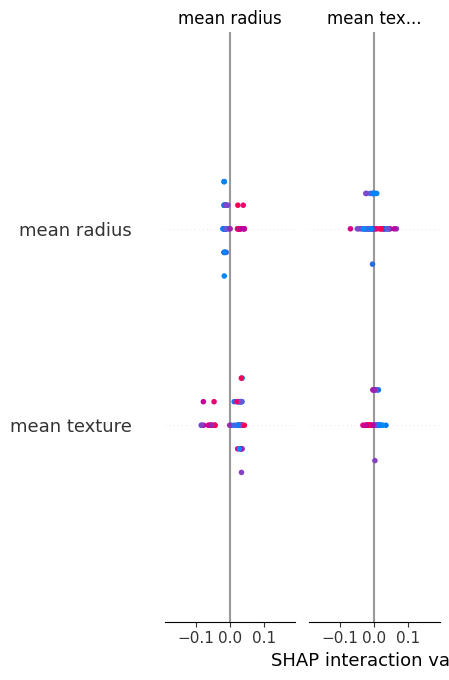


Original Prediction: 1 | Prob: [0.045 0.955]
Modified Prediction: 1 | Prob: [0.045 0.955]



Pipeline Completed Successfully


In [1]:
# ================================

# Install required libraries
import sys, subprocess
def install(pkg):
    try:
        __import__(pkg)
    except:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

install("plotly")
install("shap")

# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix

import shap

# -------------------------------
# 1. Load Data
# -------------------------------
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Dataset Shape:", df.shape)
display(df.head())

# -------------------------------
# 2. Class Distribution (Plotly)
# -------------------------------
fig = px.histogram(df, x="target", title="Cancer Class Distribution")
fig.show()

# -------------------------------
# 3. Correlation Heatmap (Plotly)
# -------------------------------
corr = df.corr()

fig = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=corr.columns,
    y=corr.columns
))
fig.update_layout(title="Correlation Heatmap")
fig.show()

# -------------------------------
# 4. Feature Scaling
# -------------------------------
X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 5. PCA Visualization
# -------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "target": y
})

fig = px.scatter(pca_df, x="PC1", y="PC2", color="target",
                 title="PCA Visualization of Cancer Data")
fig.show()

# -------------------------------
# 6. Train Model
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 7. Evaluation
# -------------------------------
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, y_pred)

fig = px.imshow(cm, text_auto=True, title="Confusion Matrix")
fig.show()

# -------------------------------
# 8. Feature Importance (Plotly)
# -------------------------------
importance = model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

fig = px.bar(feat_df.head(15),
             x="Importance", y="Feature",
             orientation="h",
             title="Top Important Features")
fig.show()

# -------------------------------
# 9. SHAP Explainability
# -------------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:50])

print("SHAP Summary Plot:")
shap.summary_plot(shap_values, X_test[:50], feature_names=X.columns)

# -------------------------------
# 10. Counterfactual Simulation
# -------------------------------
sample = X_test[0].copy()

orig_pred = model.predict([sample])[0]
orig_prob = model.predict_proba([sample])[0]

# Modify features
sample_mod = sample.copy()
sample_mod[0] *= 1.5
sample_mod[1] *= 0.5

new_pred = model.predict([sample_mod])[0]
new_prob = model.predict_proba([sample_mod])[0]

print("\nOriginal Prediction:", orig_pred, "| Prob:", orig_prob)
print("Modified Prediction:", new_pred, "| Prob:", new_prob)

# Plot comparison
fig = go.Figure(data=[
    go.Bar(name='Original', x=['Class 0','Class 1'], y=orig_prob),
    go.Bar(name='Modified', x=['Class 0','Class 1'], y=new_prob)
])
fig.update_layout(barmode='group', title="Counterfactual Prediction Comparison")
fig.show()

# -------------------------------
# 11. Sensitivity Analysis
# -------------------------------
values = np.linspace(X_test[:,0].min(), X_test[:,0].max(), 50)
preds = []

for v in values:
    temp = sample.copy()
    temp[0] = v
    preds.append(model.predict_proba([temp])[0][1])

fig = px.line(x=values, y=preds,
              title="Feature Sensitivity Analysis",
              labels={"x":"Feature Value", "y":"Probability"})
fig.show()

print("\nPipeline Completed Successfully")